In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, matthews_corrcoef, roc_auc_score
from sklearn.preprocessing import label_binarize

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import TimeDistributed, Conv2D, MaxPooling2D, Flatten, LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# --- 2. ربط Google Drive ---
drive.mount('/content/drive')

# --- 3. إعداد المسار ---
X = np.load('/content/drive/MyDrive/alphabet/images_under.npy')
y = np.load('/content/drive/MyDrive/alphabet/encoded_labels_under.npy')

print("✅ تم تحميل البيانات بنجاح")
print("شكل الصور:", X.shape)
print("شكل التسميات:", y.shape)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ تم تحميل البيانات بنجاح
شكل الصور: (32128, 64, 64, 1)
شكل التسميات: (32128,)


In [ ]:
# عدد الإطارات في كل sequence
sequence_length = 10

# عدد التسلسلات الممكنة
num_sequences = len(X) // sequence_length

# اقتص الصور عشان يتقسموا تمامًا على 10
X = X[:num_sequences * sequence_length]
y = y[:num_sequences * sequence_length]

# أعد تشكيل البيانات
X_seq = X.reshape((num_sequences, sequence_length, 64, 64, 1))
y_seq = y[::sequence_length]  # نأخذ label لكل sequence

print("✅ X_seq shape:", X_seq.shape)
print("✅ y_seq shape:", y_seq.shape)

# ✨ تقسيم البيانات Train/Val/Test
X_train, X_temp, y_train, y_temp = train_test_split(
    X_seq, y_seq, test_size=0.3, random_state=42, stratify=y_seq
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print("📊 Training data shape:", X_train.shape, y_train.shape)
print("📊 Validation data shape:", X_val.shape, y_val.shape)
print("📊 Test data shape:", X_test.shape, y_test.shape)


✅ X_seq shape: (3212, 10, 64, 64, 1)
✅ y_seq shape: (3212,)
📊 Training data shape: (2248, 10, 64, 64, 1) (2248,)
📊 Validation data shape: (482, 10, 64, 64, 1) (482,)
📊 Test data shape: (482, 10, 64, 64, 1) (482,)


In [ ]:
num_classes = len(np.unique(y_seq))
frames = X_seq.shape[1]

model = Sequential()

# Block 1
model.add(TimeDistributed(Conv2D(32, (3, 3), activation='relu', padding='same'),
                          input_shape=(frames, 64, 64, 1)))
model.add(TimeDistributed(BatchNormalization()))
model.add(TimeDistributed(MaxPooling2D(pool_size=(2, 2))))

# Block 2
model.add(TimeDistributed(Conv2D(64, (3, 3), activation='relu', padding='same')))
model.add(TimeDistributed(BatchNormalization()))
model.add(TimeDistributed(MaxPooling2D(pool_size=(2, 2))))

# Block 3
model.add(TimeDistributed(Conv2D(128, (3, 3), activation='relu', padding='same')))
model.add(TimeDistributed(BatchNormalization()))
model.add(TimeDistributed(MaxPooling2D(pool_size=(2, 2))))

# Block 4
model.add(TimeDistributed(Conv2D(256, (3, 3), activation='relu', padding='same')))
model.add(TimeDistributed(BatchNormalization()))
model.add(TimeDistributed(MaxPooling2D(pool_size=(2, 2))))

# Block 5
model.add(TimeDistributed(Conv2D(512, (3, 3), activation='relu', padding='same')))
model.add(TimeDistributed(BatchNormalization()))
model.add(TimeDistributed(MaxPooling2D(pool_size=(2, 2))))

# Flatten
model.add(TimeDistributed(Flatten()))

# LSTM
model.add(LSTM(128, return_sequences=False))
model.add(Dropout(0.5))

# Output
model.add(Dense(num_classes, activation='softmax'))

# Compile
model.compile(optimizer=Adam(1e-4),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/wrapper.py:27: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed                │ (None, 10, 64, 64, 32) │           320 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 10, 64, 64, 32) │           128 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_2              │ (None, 10, 32, 32, 32) │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_3              │ (None, 10, 32, 32, 64) │        18,496 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_4              │ (None, 10, 32, 32, 64) │           256 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_5              │ (None, 10, 16, 16, 64) │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_6              │ (None, 10, 16, 16,     │        73,856 │
│ (TimeDistributed)               │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_7              │ (None, 10, 16, 16,     │           512 │
│ (TimeDistributed)               │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_8              │ (None, 10, 8, 8, 128)  │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_9              │ (None, 10, 8, 8, 256)  │       295,168 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_10             │ (None, 10, 8, 8, 256)  │         1,024 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_11             │ (None, 10, 4, 4, 256)  │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_12             │ (None, 10, 4, 4, 512)  │     1,180,160 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_13             │ (None, 10, 4, 4, 512)  │         2,048 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_14             │ (None, 10, 2, 2, 512)  │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_15             │ (None, 10, 2048)       │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │     1,114,62

 Total params: 2,690,720 (10.26 MB)

 Trainable params: 2,688,736 (10.26 MB)

 Non-trainable params: 1,984 (7.75 KB)


================ Run 1 ================

Epoch 1/20
281/281 ━━━━━━━━━━━━━━━━━━━━ 40s 89ms/step - accuracy: 0.1366 - loss: 3.1665 - val_accuracy: 0.6950 - val_loss: 1.7723
Epoch 2/20
281/281 ━━━━━━━━━━━━━━━━━━━━ 23s 82ms/step - accuracy: 0.5682 - loss: 1.6965 - val_accuracy: 0.9440 - val_loss: 0.7306
Epoch 3/20
281/281 ━━━━━━━━━━━━━━━━━━━━ 23s 81ms/step - accuracy: 0.8272 - loss: 0.8605 - val_accuracy: 0.9751 - val_loss: 0.3507
Epoch 4/20
281/281 ━━━━━━━━━━━━━━━━━━━━ 23s 83ms/step - accuracy: 0.9501 - loss: 0.4277 - val_accuracy: 0.9896 - val_loss: 0.1726
Epoch 5/20
281/281 ━━━━━━━━━━━━━━━━━━━━ 23s 80ms/step - accuracy: 0.9816 - loss: 0.2081 - val_accuracy: 0.9938 - val_loss: 0.0991
Epoch 6/20
281/281 ━━━━━━━━━━━━━━━━━━━━ 23s 82ms/step - accuracy: 0.9896 - loss: 0.1299 - val_accuracy: 0.9959 - val_loss: 0.0756
Epoch 7/20
281/281 ━━━━━━━━━━━━━━━━━━━━ 23s 82ms/step - accuracy: 0.9931 - loss: 0.0924 - val_accuracy: 0.9938 - val_loss: 0.0556
Epoch 8/20
281/281 ━━━━━━━━━━━━━━━━━━━━ 23s 83ms

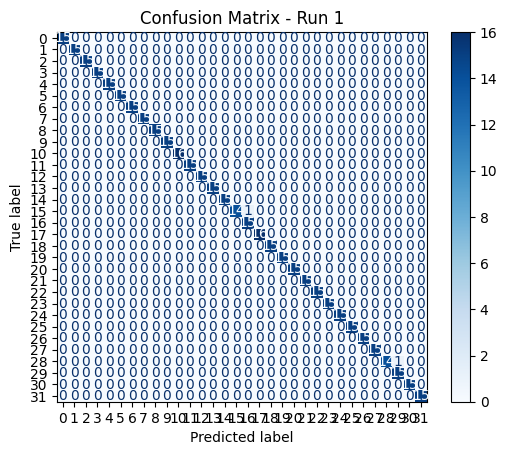

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step

================ Run 2 ================

Epoch 1/20
281/281 ━━━━━━━━━━━━━━━━━━━━ 42s 94ms/step - accuracy: 0.1017 - loss: 3.3083 - val_accuracy: 0.5498 - val_loss: 2.0984
Epoch 2/20
281/281 ━━━━━━━━━━━━━━━━━━━━ 23s 82ms/step - accuracy: 0.4729 - loss: 1.9997 - val_accuracy: 0.8921 - val_loss: 0.9248
Epoch 3/20
281/281 ━━━━━━━━━━━━━━━━━━━━ 23s 80ms/step - accuracy: 0.8193 - loss: 0.9161 - val_accuracy: 0.9772 - val_loss: 0.4244
Epoch 4/20
281/281 ━━━━━━━━━━━━━━━━━━━━ 23s 81ms/step - accuracy: 0.9291 - loss: 0.4799 - val_accuracy: 0.9917 - val_loss: 0.2249
Epoch 5/20
281/281 ━━━━━━━━━━━━━━━━━━━━ 23s 80ms/step - accuracy: 0.9729 - loss: 0.2889 - val_accuracy: 0.9959 - val_loss: 0.1106
Epoch 6/20
281/281 ━━━━━━━━━━━━━━━━━━━━ 23s 81ms/step - accuracy: 0.9887 - loss: 0.1721 - val_accuracy: 0.9938 - val_loss: 0.0869
Epoch 7/20
281/281 ━━━━━━━━━━━━━━━━━━━━ 22s 80ms/step - accuracy: 0.9942 - loss: 0.1194 - val_accuracy: 0.9959 - val_loss: 0.0629
Epoch 8/

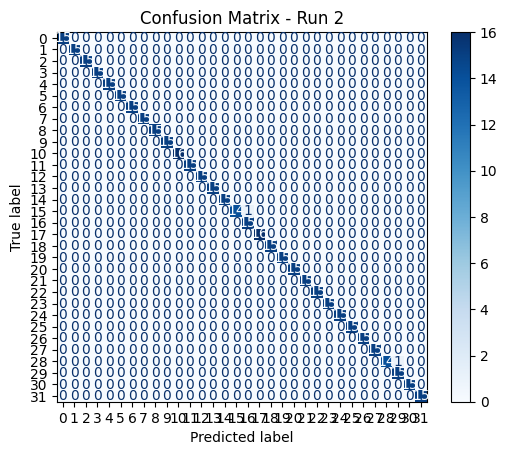

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step

================ Run 3 ================

Epoch 1/20
281/281 ━━━━━━━━━━━━━━━━━━━━ 40s 90ms/step - accuracy: 0.1246 - loss: 3.1928 - val_accuracy: 0.5685 - val_loss: 1.9789
Epoch 2/20
281/281 ━━━━━━━━━━━━━━━━━━━━ 23s 82ms/step - accuracy: 0.5076 - loss: 1.8709 - val_accuracy: 0.8714 - val_loss: 0.9469
Epoch 3/20
281/281 ━━━━━━━━━━━━━━━━━━━━ 23s 81ms/step - accuracy: 0.7716 - loss: 1.0403 - val_accuracy: 0.9627 - val_loss: 0.4709
Epoch 4/20
281/281 ━━━━━━━━━━━━━━━━━━━━ 23s 81ms/step - accuracy: 0.9020 - loss: 0.5673 - val_accuracy: 0.9855 - val_loss: 0.2122
Epoch 5/20
281/281 ━━━━━━━━━━━━━━━━━━━━ 41s 81ms/step - accuracy: 0.9728 - loss: 0.3068 - val_accuracy: 0.9896 - val_loss: 0.1453
Epoch 6/20
281/281 ━━━━━━━━━━━━━━━━━━━━ 23s 82ms/step - accuracy: 0.9849 - loss: 0.1827 - val_accuracy: 0.9938 - val_loss: 0.0824
Epoch 7/20
281/281 ━━━━━━━━━━━━━━━━━━━━ 23s 81ms/step - accuracy: 0.9955 - loss: 0.1109 - val_accuracy: 0.9979 - val_loss: 0.0541
Epoch 8/

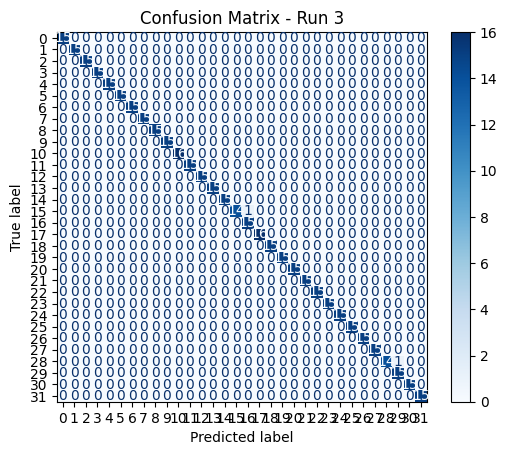

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step

================ Run 4 ================

Epoch 1/20
281/281 ━━━━━━━━━━━━━━━━━━━━ 41s 95ms/step - accuracy: 0.0931 - loss: 3.3390 - val_accuracy: 0.5041 - val_loss: 2.2982
Epoch 2/20
281/281 ━━━━━━━━━━━━━━━━━━━━ 23s 81ms/step - accuracy: 0.4395 - loss: 2.1608 - val_accuracy: 0.8651 - val_loss: 1.1626
Epoch 3/20
281/281 ━━━━━━━━━━━━━━━━━━━━ 23s 82ms/step - accuracy: 0.7363 - loss: 1.2074 - val_accuracy: 0.9606 - val_loss: 0.4976
Epoch 4/20
281/281 ━━━━━━━━━━━━━━━━━━━━ 23s 81ms/step - accuracy: 0.9207 - loss: 0.5587 - val_accuracy: 0.9689 - val_loss: 0.2673
Epoch 5/20
281/281 ━━━━━━━━━━━━━━━━━━━━ 23s 81ms/step - accuracy: 0.9654 - loss: 0.3265 - val_accuracy: 0.9938 - val_loss: 0.1476
Epoch 6/20
281/281 ━━━━━━━━━━━━━━━━━━━━ 23s 81ms/step - accuracy: 0.9865 - loss: 0.2056 - val_accuracy: 0.9938 - val_loss: 0.0964
Epoch 7/20
281/281 ━━━━━━━━━━━━━━━━━━━━ 23s 81ms/step - accuracy: 0.9903 - loss: 0.1525 - val_accuracy: 0.9917 - val_loss: 0.0822
Epoch 8/

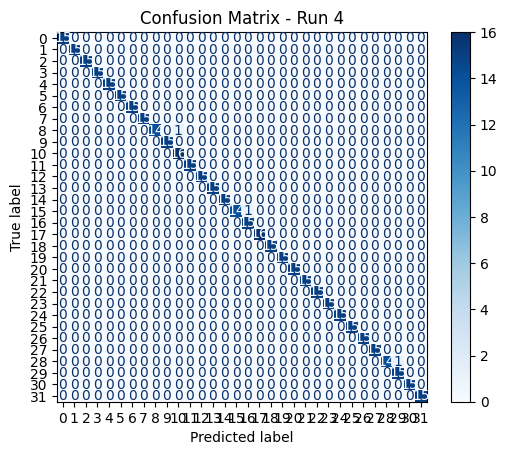

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step

================ Run 5 ================

Epoch 1/20
281/281 ━━━━━━━━━━━━━━━━━━━━ 40s 90ms/step - accuracy: 0.1198 - loss: 3.2039 - val_accuracy: 0.5809 - val_loss: 2.0184
Epoch 2/20
281/281 ━━━━━━━━━━━━━━━━━━━━ 23s 83ms/step - accuracy: 0.4982 - loss: 1.9412 - val_accuracy: 0.8568 - val_loss: 1.0078
Epoch 3/20
281/281 ━━━━━━━━━━━━━━━━━━━━ 41s 82ms/step - accuracy: 0.7678 - loss: 1.0407 - val_accuracy: 0.9461 - val_loss: 0.4661
Epoch 4/20
281/281 ━━━━━━━━━━━━━━━━━━━━ 23s 82ms/step - accuracy: 0.9100 - loss: 0.5198 - val_accuracy: 0.9793 - val_loss: 0.2276
Epoch 5/20
281/281 ━━━━━━━━━━━━━━━━━━━━ 23s 82ms/step - accuracy: 0.9704 - loss: 0.2598 - val_accuracy: 0.9959 - val_loss: 0.1432
Epoch 6/20
281/281 ━━━━━━━━━━━━━━━━━━━━ 23s 81ms/step - accuracy: 0.9804 - loss: 0.1781 - val_accuracy: 0.9979 - val_loss: 0.0887
Epoch 7/20
281/281 ━━━━━━━━━━━━━━━━━━━━ 23s 82ms/step - accuracy: 0.9891 - loss: 0.1296 - val_accuracy: 0.9917 - val_loss: 0.0855
Epoch 8/

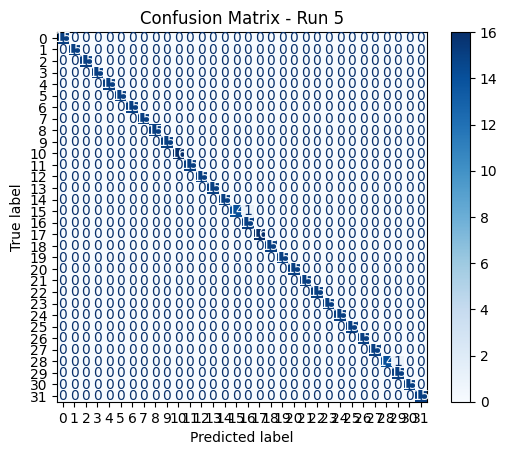

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step

================ Run 6 ================

Epoch 1/20
281/281 ━━━━━━━━━━━━━━━━━━━━ 40s 91ms/step - accuracy: 0.1079 - loss: 3.3132 - val_accuracy: 0.4896 - val_loss: 2.1619
Epoch 2/20
281/281 ━━━━━━━━━━━━━━━━━━━━ 23s 82ms/step - accuracy: 0.4383 - loss: 2.0415 - val_accuracy: 0.9025 - val_loss: 1.0522
Epoch 3/20
281/281 ━━━━━━━━━━━━━━━━━━━━ 23s 82ms/step - accuracy: 0.7930 - loss: 1.0602 - val_accuracy: 0.9357 - val_loss: 0.5216
Epoch 4/20
281/281 ━━━━━━━━━━━━━━━━━━━━ 23s 82ms/step - accuracy: 0.9157 - loss: 0.5731 - val_accuracy: 0.9855 - val_loss: 0.2577
Epoch 5/20
281/281 ━━━━━━━━━━━━━━━━━━━━ 23s 81ms/step - accuracy: 0.9597 - loss: 0.3273 - val_accuracy: 0.9917 - val_loss: 0.1290
Epoch 6/20
281/281 ━━━━━━━━━━━━━━━━━━━━ 23s 81ms/step - accuracy: 0.9929 - loss: 0.1533 - val_accuracy: 0.9959 - val_loss: 0.0942
Epoch 7/20
281/281 ━━━━━━━━━━━━━━━━━━━━ 23s 82ms/step - accuracy: 0.9919 - loss: 0.1163 - val_accuracy: 0.9959 - val_loss: 0.0648
Epoch 8/

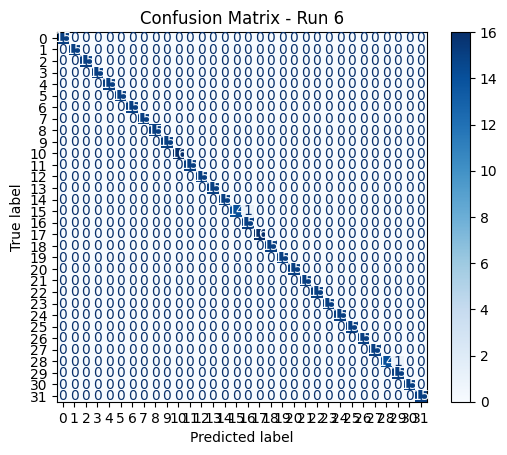

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step

================ Run 7 ================

Epoch 1/20
281/281 ━━━━━━━━━━━━━━━━━━━━ 40s 91ms/step - accuracy: 0.1266 - loss: 3.2113 - val_accuracy: 0.5622 - val_loss: 2.1850
Epoch 2/20
281/281 ━━━━━━━━━━━━━━━━━━━━ 23s 83ms/step - accuracy: 0.4741 - loss: 1.9985 - val_accuracy: 0.8755 - val_loss: 0.9500
Epoch 3/20
281/281 ━━━━━━━━━━━━━━━━━━━━ 23s 82ms/step - accuracy: 0.7668 - loss: 1.0602 - val_accuracy: 0.9378 - val_loss: 0.4693
Epoch 4/20
281/281 ━━━━━━━━━━━━━━━━━━━━ 23s 82ms/step - accuracy: 0.9352 - loss: 0.5100 - val_accuracy: 0.9938 - val_loss: 0.2310
Epoch 5/20
281/281 ━━━━━━━━━━━━━━━━━━━━ 23s 82ms/step - accuracy: 0.9616 - loss: 0.3266 - val_accuracy: 0.9876 - val_loss: 0.1520
Epoch 6/20
281/281 ━━━━━━━━━━━━━━━━━━━━ 24s 86ms/step - accuracy: 0.9901 - loss: 0.1654 - val_accuracy: 0.9959 - val_loss: 0.0845
Epoch 7/20
281/281 ━━━━━━━━━━━━━━━━━━━━ 24s 86ms/step - accuracy: 0.9898 - loss: 0.1399 - val_accuracy: 0.9959 - val_loss: 0.0660
Epoch 8/

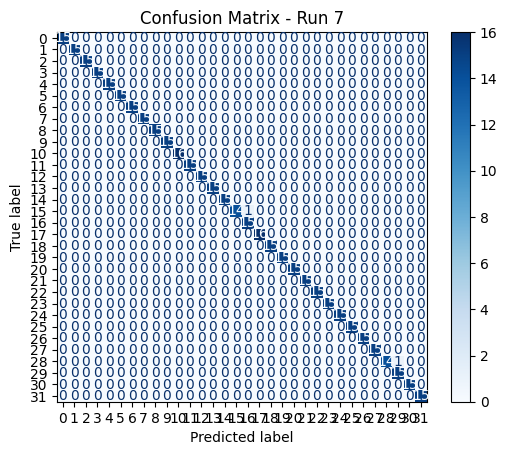

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step

================ Run 8 ================

Epoch 1/20
281/281 ━━━━━━━━━━━━━━━━━━━━ 40s 92ms/step - accuracy: 0.1063 - loss: 3.2980 - val_accuracy: 0.5934 - val_loss: 2.0876
Epoch 2/20
281/281 ━━━━━━━━━━━━━━━━━━━━ 24s 84ms/step - accuracy: 0.5093 - loss: 1.9468 - val_accuracy: 0.8817 - val_loss: 0.9799
Epoch 3/20
281/281 ━━━━━━━━━━━━━━━━━━━━ 23s 82ms/step - accuracy: 0.8073 - loss: 0.9881 - val_accuracy: 0.9627 - val_loss: 0.4139
Epoch 4/20
281/281 ━━━━━━━━━━━━━━━━━━━━ 23s 82ms/step - accuracy: 0.9494 - loss: 0.4110 - val_accuracy: 0.9751 - val_loss: 0.2470
Epoch 5/20
281/281 ━━━━━━━━━━━━━━━━━━━━ 41s 83ms/step - accuracy: 0.9668 - loss: 0.2767 - val_accuracy: 0.9959 - val_loss: 0.1167
Epoch 6/20
281/281 ━━━━━━━━━━━━━━━━━━━━ 23s 83ms/step - accuracy: 0.9909 - loss: 0.1621 - val_accuracy: 0.9959 - val_loss: 0.0791
Epoch 7/20
281/281 ━━━━━━━━━━━━━━━━━━━━ 23s 82ms/step - accuracy: 0.9938 - loss: 0.1049 - val_accuracy: 0.9959 - val_loss: 0.0507
Epoch 8/

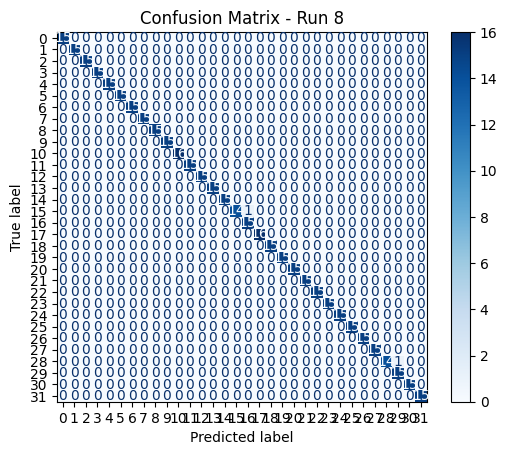

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step

================ Run 9 ================

Epoch 1/20
281/281 ━━━━━━━━━━━━━━━━━━━━ 41s 92ms/step - accuracy: 0.1384 - loss: 3.1854 - val_accuracy: 0.6598 - val_loss: 1.8073
Epoch 2/20
281/281 ━━━━━━━━━━━━━━━━━━━━ 23s 84ms/step - accuracy: 0.5108 - loss: 1.8800 - val_accuracy: 0.8880 - val_loss: 0.9025
Epoch 3/20
281/281 ━━━━━━━━━━━━━━━━━━━━ 23s 83ms/step - accuracy: 0.7852 - loss: 0.9914 - val_accuracy: 0.9689 - val_loss: 0.4039
Epoch 4/20
281/281 ━━━━━━━━━━━━━━━━━━━━ 23s 83ms/step - accuracy: 0.9304 - loss: 0.4730 - val_accuracy: 0.9855 - val_loss: 0.1882
Epoch 5/20
281/281 ━━━━━━━━━━━━━━━━━━━━ 24s 84ms/step - accuracy: 0.9811 - loss: 0.2396 - val_accuracy: 0.9938 - val_loss: 0.1119
Epoch 6/20
281/281 ━━━━━━━━━━━━━━━━━━━━ 23s 83ms/step - accuracy: 0.9897 - loss: 0.1503 - val_accuracy: 0.9959 - val_loss: 0.0663
Epoch 7/20
281/281 ━━━━━━━━━━━━━━━━━━━━ 23s 83ms/step - accuracy: 0.9947 - loss: 0.0994 - val_accuracy: 0.9938 - val_loss: 0.0531
Epoch 8/

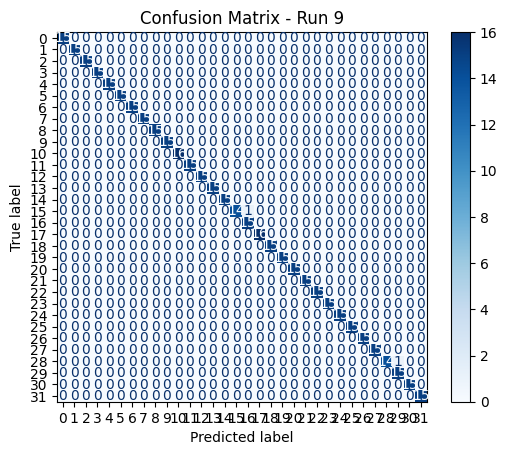

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step

================ Run 10 ================

Epoch 1/20
281/281 ━━━━━━━━━━━━━━━━━━━━ 41s 94ms/step - accuracy: 0.1339 - loss: 3.1775 - val_accuracy: 0.6535 - val_loss: 1.8739
Epoch 2/20
281/281 ━━━━━━━━━━━━━━━━━━━━ 24s 84ms/step - accuracy: 0.4981 - loss: 1.8391 - val_accuracy: 0.9004 - val_loss: 0.9317
Epoch 3/20
281/281 ━━━━━━━━━━━━━━━━━━━━ 23s 83ms/step - accuracy: 0.8025 - loss: 0.9582 - val_accuracy: 0.9585 - val_loss: 0.4339
Epoch 4/20
281/281 ━━━━━━━━━━━━━━━━━━━━ 24s 84ms/step - accuracy: 0.9330 - loss: 0.4736 - val_accuracy: 0.9793 - val_loss: 0.2255
Epoch 5/20
281/281 ━━━━━━━━━━━━━━━━━━━━ 24s 84ms/step - accuracy: 0.9689 - loss: 0.2805 - val_accuracy: 0.9917 - val_loss: 0.1083
Epoch 6/20
281/281 ━━━━━━━━━━━━━━━━━━━━ 24s 84ms/step - accuracy: 0.9902 - loss: 0.1413 - val_accuracy: 0.9959 - val_loss: 0.0903
Epoch 7/20
281/281 ━━━━━━━━━━━━━━━━━━━━ 24s 84ms/step - accuracy: 0.9944 - loss: 0.1165 - val_accuracy: 0.9959 - val_loss: 0.0573
Epoch 8

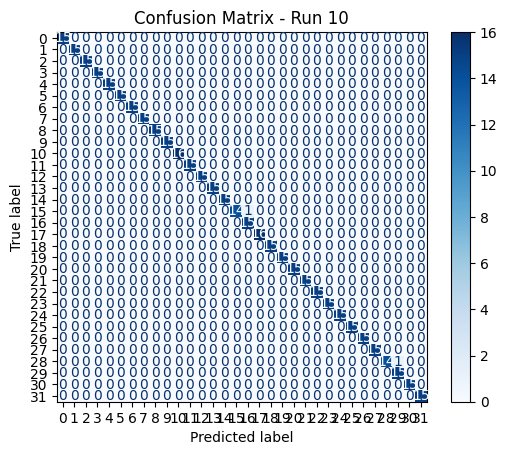

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step
   Run  Val_Accuracy  Val_Loss       MCC  ROC_AUC  F1_Weighted  \
0    1      0.995851  0.019020  0.995726      1.0     0.995846   
1    2      0.995851  0.014143  0.995726      1.0     0.995846   
2    3      0.995851  0.016820  0.995726      1.0     0.995846   
3    4      0.993776  0.033855  0.993588      1.0     0.993767   
4    5      0.995851  0.019125  0.995726      1.0     0.995846   
5    6      0.995851  0.020543  0.995726      1.0     0.995846   
6    7      0.995851  0.011627  0.995726      1.0     0.995846   
7    8      0.995851  0.016832  0.995726      1.0     0.995846   
8    9      0.995851  0.014921  0.995726      1.0     0.995846   
9   10      0.995851  0.020702  0.995726      1.0     0.995846   

   Precision_Weighted  Recall_Weighted  Training_Time(s)  Memory_Used(MB)  
0            0.996110         0.995851        497.765136       224.101562  
1            0.996110         0.995851        510.435865       264.925781  
2    

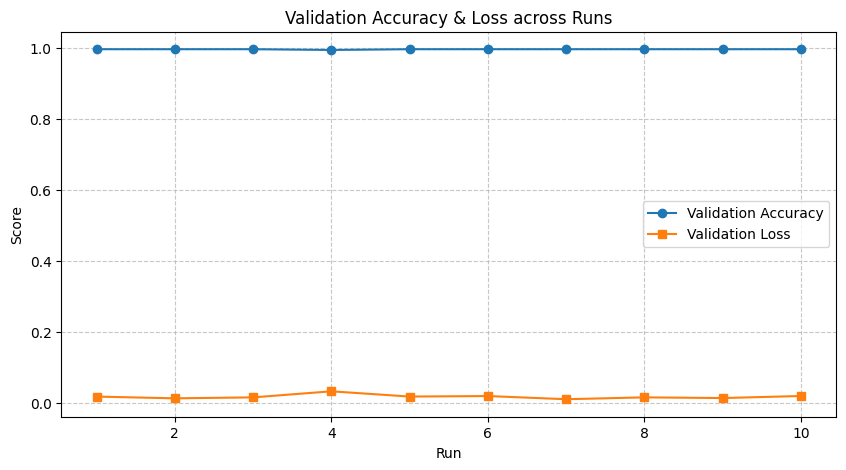

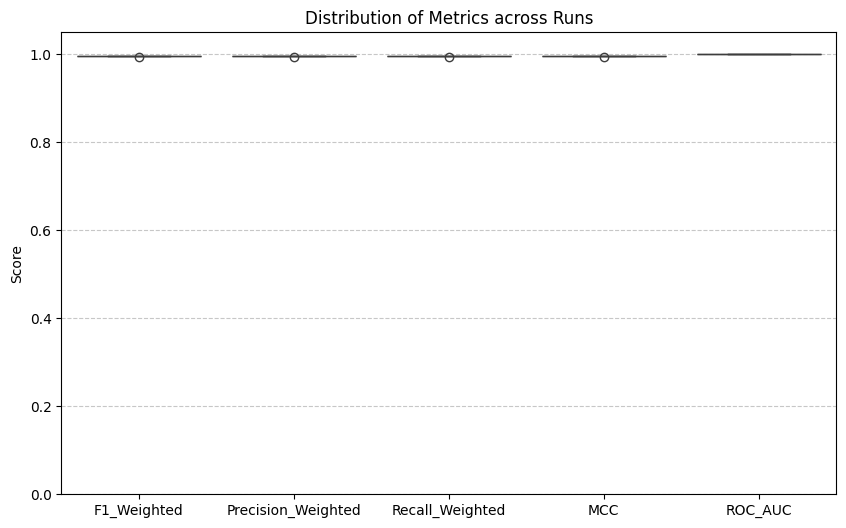

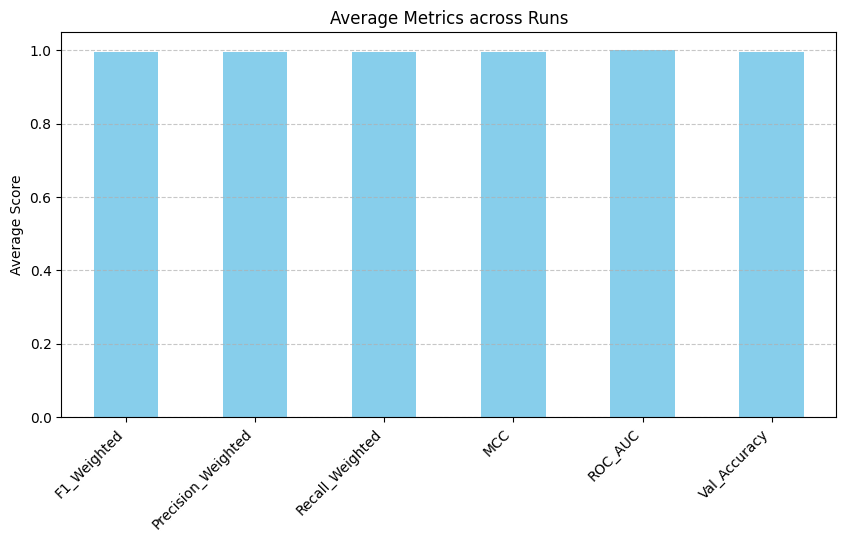

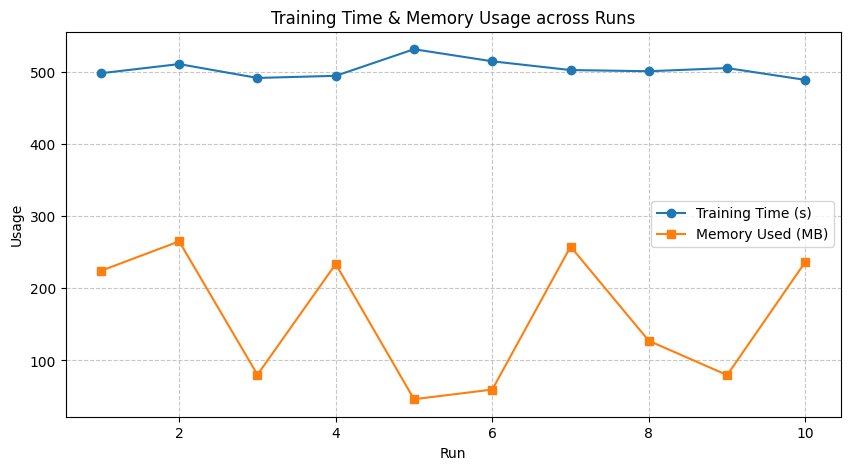

In [ ]:
import time
import psutil
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, matthews_corrcoef, roc_auc_score, f1_score, precision_score, recall_score
from sklearn.preprocessing import label_binarize
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.optimizers import Adam

results = []
num_runs = 10  # عدد مرات التشغيل

for run in range(1, num_runs+1):
    print(f"\n================ Run {run} ================\n")

    # --- قياس الوقت والذاكرة قبل التدريب ---
    start_time = time.time()
    start_mem = psutil.Process().memory_info().rss / (1024 ** 2)  # MB

    # إعادة بناء الموديل كل Run
    model_run = tf.keras.models.clone_model(model)
    model_run.compile(optimizer=Adam(1e-4),
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

    # تدريب النموذج
    history = model_run.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=20,
        batch_size=8,
        verbose=1
    )

    # --- قياس الوقت والذاكرة بعد التدريب ---
    end_time = time.time()
    end_mem = psutil.Process().memory_info().rss / (1024 ** 2)
    train_time = end_time - start_time
    train_memory = end_mem - start_mem

    # تقييم
    val_loss, val_acc = model_run.evaluate(X_val, y_val, verbose=0)

    # --- Confusion Matrix ---
    y_pred = np.argmax(model_run.predict(X_val), axis=1)
    cm = confusion_matrix(y_val, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f"Confusion Matrix - Run {run}")
    plt.show()

    # --- MCC ---
    mcc = matthews_corrcoef(y_val, y_pred)

    # --- ROC AUC ---
    y_val_bin = label_binarize(y_val, classes=np.arange(num_classes))
    y_pred_prob = model_run.predict(X_val)
    roc_auc = roc_auc_score(y_val_bin, y_pred_prob, average='macro', multi_class='ovr')

    # --- Weighted Metrics ---
    f1_w = f1_score(y_val, y_pred, average='weighted')
    precision_w = precision_score(y_val, y_pred, average='weighted')
    recall_w = recall_score(y_val, y_pred, average='weighted')

    # حفظ النتائج
    results.append({
        'Run': run,
        'Val_Accuracy': val_acc,
        'Val_Loss': val_loss,
        'MCC': mcc,
        'ROC_AUC': roc_auc,
        'F1_Weighted': f1_w,
        'Precision_Weighted': precision_w,
        'Recall_Weighted': recall_w,
        'Training_Time(s)': train_time,
        'Memory_Used(MB)': train_memory
    })

# --- تحويل النتائج ل DataFrame ---
df_results = pd.DataFrame(results)
print(df_results)

# --- حفظ النتائج ---
df_results.to_excel("metrics_with_f1_precision_recall_time_memory.xlsx", index=False)
print("\n✅ Saved to metrics_with_f1_precision_recall_time_memory.xlsx")

# =================== 📊 الرسومات ===================

# 1. Accuracy & Loss عبر الـ Runs
plt.figure(figsize=(10,5))
plt.plot(df_results['Run'], df_results['Val_Accuracy'], marker='o', label='Validation Accuracy')
plt.plot(df_results['Run'], df_results['Val_Loss'], marker='s', label='Validation Loss')
plt.xlabel("Run")
plt.ylabel("Score")
plt.title("Validation Accuracy & Loss across Runs")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.7)
plt.show()

# 2. Boxplot للـ Metrics
metrics_cols = ['F1_Weighted', 'Precision_Weighted', 'Recall_Weighted', 'MCC', 'ROC_AUC']
plt.figure(figsize=(10,6))
sns.boxplot(data=df_results[metrics_cols])
plt.title("Distribution of Metrics across Runs")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.grid(axis='y', linestyle="--", alpha=0.7)
plt.show()

# 3. Bar chart للمتوسطات
avg_results = df_results.mean(numeric_only=True)
plt.figure(figsize=(10,5))
avg_results[metrics_cols + ['Val_Accuracy']].plot(kind='bar', color='skyblue')
plt.title("Average Metrics across Runs")
plt.ylabel("Average Score")
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1.05)
plt.grid(axis='y', linestyle="--", alpha=0.7)
plt.show()

# 4. Training Time & Memory Usage
plt.figure(figsize=(10,5))
plt.plot(df_results['Run'], df_results['Training_Time(s)'], marker='o', label='Training Time (s)')
plt.plot(df_results['Run'], df_results['Memory_Used(MB)'], marker='s', label='Memory Used (MB)')
plt.xlabel("Run")
plt.ylabel("Usage")
plt.title("Training Time & Memory Usage across Runs")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.7)
plt.show()


In [ ]:
df_results = pd.DataFrame(results)
df_results.to_excel('/content/drive/MyDrive/alphabet/CNN_Lstm_analysis_under.xlsx', index=False)
print("✅ Results saved to CNN_runs_analysis.xlsx")
print(df_results)


✅ Results saved to CNN_runs_analysis.xlsx
   Run  Val_Accuracy  Val_Loss       MCC  ROC_AUC  F1_Weighted  \
0    1      0.995851  0.019020  0.995726      1.0     0.995846   
1    2      0.995851  0.014143  0.995726      1.0     0.995846   
2    3      0.995851  0.016820  0.995726      1.0     0.995846   
3    4      0.993776  0.033855  0.993588      1.0     0.993767   
4    5      0.995851  0.019125  0.995726      1.0     0.995846   
5    6      0.995851  0.020543  0.995726      1.0     0.995846   
6    7      0.995851  0.011627  0.995726      1.0     0.995846   
7    8      0.995851  0.016832  0.995726      1.0     0.995846   
8    9      0.995851  0.014921  0.995726      1.0     0.995846   
9   10      0.995851  0.020702  0.995726      1.0     0.995846   

   Precision_Weighted  Recall_Weighted  Training_Time(s)  Memory_Used(MB)  
0            0.996110         0.995851        497.765136       224.101562  
1            0.996110         0.995851        510.435865       264.925781  
2  


📊 Average Results across all runs:
Average Accuracy        : 0.9956
Average Loss            : 0.0188
Average MCC             : 0.9955
Average ROC AUC         : 1.0000
Average F1_Weighted     : 0.9956
Average Precision_W     : 0.9959
Average Recall_W        : 0.9956
Average Training Time(s): 503.50
Average Memory Used(MB) : 161.01

✅ Results saved to /content/drive/MyDrive/CNN_Lstm_results_under_average.xlsx


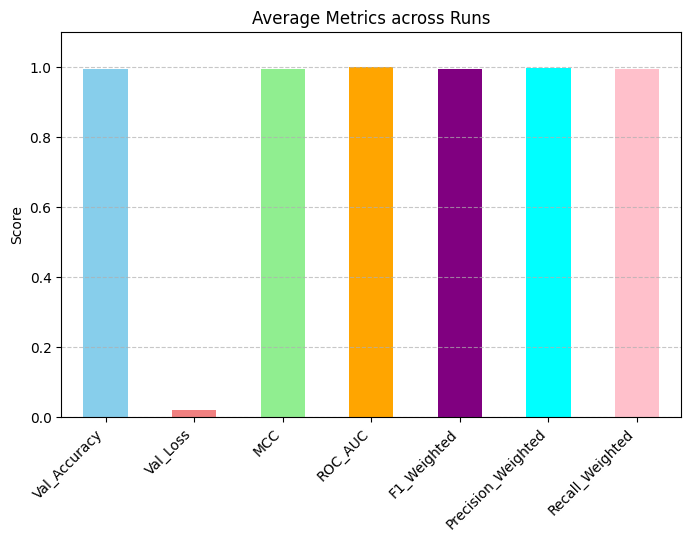

In [ ]:
import matplotlib.pyplot as plt

# --- تحويل النتائج ل DataFrame ---
results_df = pd.DataFrame(results)

# --- حساب المتوسط لكل مقياس ---
avg_results = results_df.mean(numeric_only=True)

print("\n📊 Average Results across all runs:")
print(f"Average Accuracy        : {avg_results['Val_Accuracy']:.4f}")
print(f"Average Loss            : {avg_results['Val_Loss']:.4f}")
print(f"Average MCC             : {avg_results['MCC']:.4f}")
print(f"Average ROC AUC         : {avg_results['ROC_AUC']:.4f}")
print(f"Average F1_Weighted     : {avg_results['F1_Weighted']:.4f}")
print(f"Average Precision_W     : {avg_results['Precision_Weighted']:.4f}")
print(f"Average Recall_W        : {avg_results['Recall_Weighted']:.4f}")
print(f"Average Training Time(s): {avg_results['Training_Time(s)']:.2f}")
print(f"Average Memory Used(MB) : {avg_results['Memory_Used(MB)']:.2f}")

# --- حفظ النتائج في Excel ---
save_path = "/content/drive/MyDrive/CNN_Lstm_results_under_average.xlsx"
with pd.ExcelWriter(save_path) as writer:
    results_df.to_excel(writer, sheet_name="All Runs", index=False)
    avg_results.to_frame(name="Average").to_excel(writer, sheet_name="Average")

print(f"\n✅ Results saved to {save_path}")

# --- رسم المتوسطات (المقاييس من 0 لـ 1 فقط) ---
plt.figure(figsize=(8,5))
avg_results[['Val_Accuracy','Val_Loss','MCC','ROC_AUC','F1_Weighted','Precision_Weighted','Recall_Weighted']].plot(
    kind='bar',
    color=['skyblue','lightcoral','lightgreen','orange','purple','cyan','pink']
)
plt.title("Average Metrics across Runs")
plt.ylabel("Score")
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1.1)  # معظم المقاييس بتبقى بين 0 و 1
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


In [ ]:
print("Model input shape:", model.input_shape)


Model input shape: (None, 10, 64, 64, 1)


📐 Sequential Input Shape: T=10 × 64x64x1


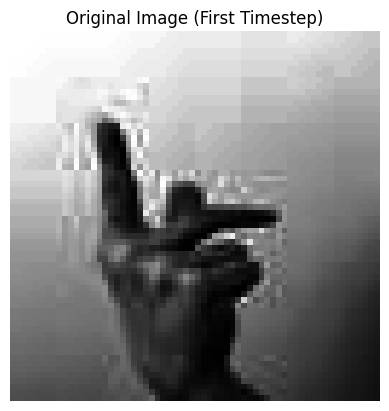

Predicted class: dha (1.00)


  0%|          | 0/1000 [00:00<?, ?it/s]

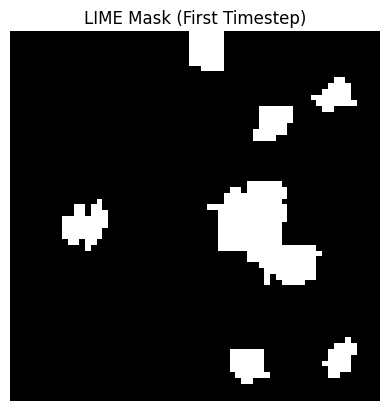

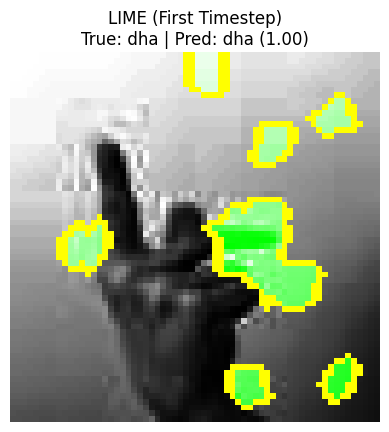

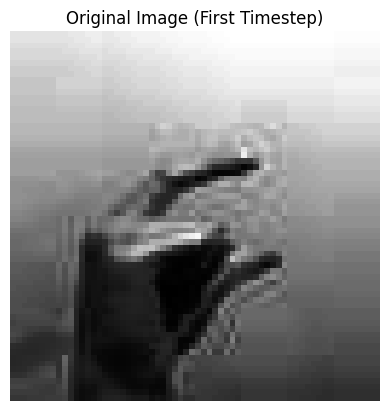

Predicted class: dal (1.00)


  0%|          | 0/1000 [00:00<?, ?it/s]

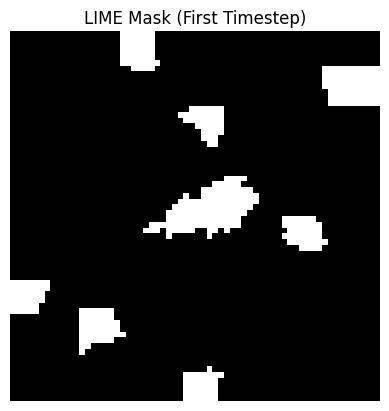

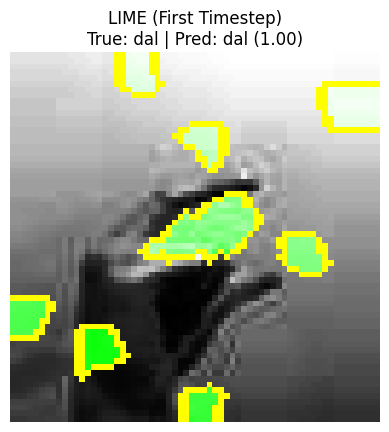

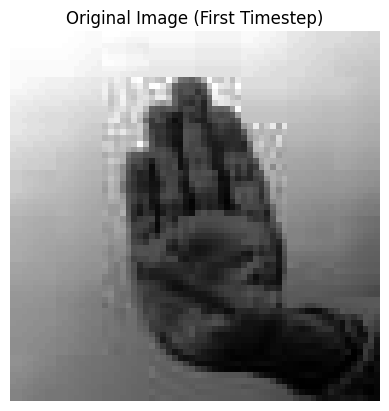

Predicted class: kaaf (1.00)


  0%|          | 0/1000 [00:00<?, ?it/s]

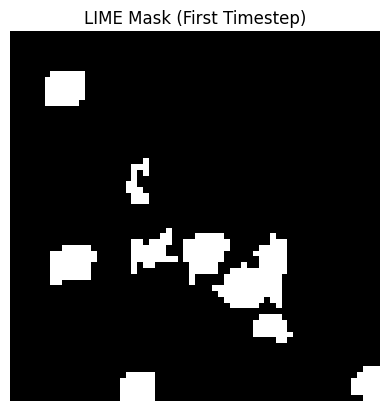

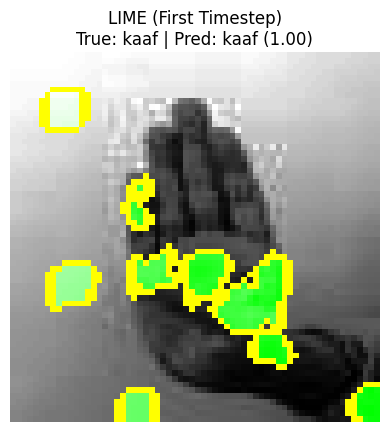

In [ ]:
!pip install lime
import numpy as np
import matplotlib.pyplot as plt
from lime import lime_image
from skimage.segmentation import mark_boundaries, slic
from skimage.transform import resize
from skimage.color import rgb2gray  # Add for grayscale conversion

# تحميل أسماء الكلاسات
class_names = np.load('/content/drive/MyDrive/alphabet/label_encoder_classes.npy', allow_pickle=True)

# استخراج شكل مدخلات الموديل
full_input_shape = model.input_shape  # e.g., (None, 10, 64, 64, 1)
input_shape = full_input_shape[1:]    # Remove batch dim: e.g., (10, 64, 64, 1)

T = 1
if len(input_shape) == 4 and input_shape[0] == 10 and input_shape[-1] == 1:
    T, H, W, C = input_shape  # T=10 timesteps, H/W=64, C=1 (grayscale)
    print(f"📐 Sequential Input Shape: T={T} × {H}x{W}x{C}")
elif len(input_shape) == 1:
    # 1D input (flattened): infer H, W, C assuming square grayscale (C=1) or adjust as needed
    features = input_shape[0]
    H = int(np.sqrt(features))  # Assume square; adjust if rectangular
    W = H
    C = 1  # Grayscale; set to 3 if flattened RGB
    print(f"📐 Inferred Input Shape (flattened): T={T} × {H}x{W}x{C} (total features: {features})")
elif len(input_shape) == 3:
    H, W, C = input_shape
    print(f"📐 Input Shape: T={T} × {H}x{W}x{C}")
else:
    raise ValueError(f"Unsupported input shape: {input_shape}")

# دالة تجهيز الصور زي التدريب (updated for sequential input)
def preprocess_batch(images):
    # images: list of data items, each potentially (T, H, W, C) or raw
    out = []
    for item in images:
        item = np.asarray(item)
        if item.ndim == 4 and item.shape == input_shape:  # Already (T, H, W, 1)
            im = item
        elif item.ndim == 2:  # Grayscale 2D: expand to (T, H, W, 1)
            im = np.expand_dims(item, axis=(0, -1))  # (1, H, W, 1)
            if T > 1:
                im = np.repeat(im, T, axis=0)  # Duplicate across timesteps if input is static
        elif item.ndim == 3 and item.shape[-1] == 1:  # (H, W, 1): expand to (T, H, W, 1)
            im = np.expand_dims(item, axis=0)  # (1, H, W, 1)
            if T > 1:
                im = np.repeat(im, T, axis=0)
        elif item.ndim == 3 and item.shape[-1] == 3:  # RGB image: convert to grayscale first
            gray = rgb2gray(item)  # Convert to (H, W)
            im = np.expand_dims(gray, axis=(0, -1))  # (1, H, W, 1)
            if T > 1:
                im = np.repeat(im, T, axis=0)  # Duplicate across timesteps
        else:
            # Fallback: assume it's the full sequence or handle differently
            if item.ndim == 5 and item.shape[1:] == input_shape:
                im = item[0]  # Take first batch if accidentally batched
            else:
                raise ValueError(f"Unexpected item shape: {item.shape}")

        # Resize each timestep if needed (preserves T)
        resized = np.zeros(input_shape, dtype='float32')
        for t in range(T):
            frame = im[t, :, :, 0] if C == 1 else im[t]
            frame_resized = resize(frame, (H, W), preserve_range=True, anti_aliasing=True).astype('float32')
            resized[t, :, :, 0] = frame_resized
        im = resized

        if im.max() > 1.0:
            im = im / 255.0
        out.append(im)
    return np.asarray(out, dtype='float32')

# دالة التنبؤ لـ LIME
def predict_fn(images):
    Xb = preprocess_batch(images)
    return model.predict(Xb, verbose=0)

# إنشاء مفسر LIME
explainer = lime_image.LimeImageExplainer()

# اختيار صور عشوائية للتفسير
indices = np.random.choice(len(X_val), size=3, replace=False)

for idx in indices:
    data_item = X_val[idx]  # Assume (T, H, W, C)

    # تجهيز نسخة RGB للعرض (use first timestep as representative)
    if data_item.ndim == 4:
        frame = data_item[0]  # First timestep
    else:
        frame = data_item
    if frame.ndim == 2 or frame.shape[-1] == 1:
        image_rgb = np.repeat(frame[..., np.newaxis], 3, axis=-1)
        image_rgb = np.squeeze(image_rgb)
    else:
        image_rgb = frame[..., :3]

    # --- عرض الصورة الأصلية (first frame) ---
    plt.figure()
    plt.imshow(image_rgb, cmap='gray' if C == 1 else None)
    plt.title("Original Image (First Timestep)")
    plt.axis('off')
    plt.show()

    # --- تنبؤ الموديل ---
    pred_probs = model.predict(preprocess_batch([data_item]), verbose=0)[0]
    pred_label = int(np.argmax(pred_probs))
    print(f"Predicted class: {class_names[pred_label]} ({pred_probs[pred_label]:.2f})")

    # --- تفسير LIME (on first frame as static image) ---
    explanation = explainer.explain_instance(
        image_rgb.astype('double'),  # Use double for precision
        predict_fn,
        labels=[pred_label],
        hide_color=0,
        num_samples=1000,
        segmentation_fn=slic
    )

    # --- استخراج الـ mask ---
    temp, mask = explanation.get_image_and_mask(
        pred_label,
        positive_only=False,
        num_features=10,
        hide_rest=False
    )

    # --- عرض الـ mask ---
    plt.figure()
    plt.imshow(mask, cmap='gray')
    plt.title("LIME Mask (First Timestep)")
    plt.axis('off')
    plt.show()

    # --- عرض الصورة مع الحدود ---
    true_class_name = class_names[int(y_val[idx])]
    predicted_class_name = class_names[pred_label]
    plt.figure()
    plt.imshow(mark_boundaries(temp, mask))
    plt.title(f"LIME (First Timestep)\nTrue: {true_class_name} | Pred: {predicted_class_name} ({pred_probs[pred_label]:.2f})")
    plt.axis('off')
    plt.show()

In [ ]:
import numpy as np

# حفظ الموديل بصيغة Keras الجديدة
model.save('/content/drive/MyDrive/my_modelcnn_lstm_under.keras')

# حفظ بيانات validation (لو محتاجة تكمل عليها)
np.save('/content/drive/MyDrive/x_val_cnn_Lstm_under.npy', X_val)
np.save('/content/drive/MyDrive/y_val_cnn_lstm_under.npy', y_val)
